In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Visualizations setup
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [14]:
# Load Dataset from data directory
df = pd.read_excel("../data/Raw dataset.xlsx")

print(f"Dataset Shape: {df.shape}")
print("\n--- First 5 Rows ---")
df.head()

Dataset Shape: (10000, 9)

--- First 5 Rows ---


,Student_ID,Age,Education,Branch,CGPA,Skills,Interest,Preferred_Work_Mode,Career
0,STU00001,28,MCA,CSE,7.62,"SQL, JavaScript, Docker, Java, AWS, Tableau, K...",Mobile Development,Hybrid,Data Scientist
1,STU00002,25,B.Sc,ME,7.55,"Docker, SQL, Machine Learning",Data Analytics,Onsite,Business Analyst
2,STU00003,30,B.Tech,AIML,9.31,"Node.js, Excel, Azure, SQL, Docker",Web Development,Remote,Business Analyst
3,STU00004,24,B.Tech,AIML,8.26,"Statistics, C++, Docker, Java, Tableau, Flask,...",UI/UX,Onsite,DevOps Engineer
4,STU00005,29,B.Tech,ECE,8.14,"C++, Docker, HTML, AWS",DevOps,Onsite,DevOps Engineer


In [15]:
print("--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Data Types & Info ---")
print(df.info())

print("\n--- Numerical Columns Stats ---")
df.describe()

--- Missing Values Check ---
Student_ID             0
Age                    0
Education              0
Branch                 0
CGPA                   0
Skills                 0
Interest               0
Preferred_Work_Mode    0
Career                 0
dtype: int64

--- Data Types & Info ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Education            10000 non-null  str    
 3   Branch               10000 non-null  str    
 4   CGPA                 10000 non-null  float64
 5   Skills               10000 non-null  str    
 6   Interest             10000 non-null  str    
 7   Preferred_Work_Mode  10000 non-null  str    
 8   Career               10000 non-null  str    
dtypes: float64(1), int64(1), str(7)
memory usage: 1.6 MB
No

,Age,CGPA
count,10000.000000,10000.000000
mean,26.492500,7.789703
std,5.228028,0.796118
min,18.000000,5.800000
25%,22.000000,7.260000
50%,26.000000,7.790000
75%,31.000000,8.330000
max,35.000000,9.900000


C:\Users\NITRO GAMING\AppData\Local\Temp\ipykernel_11916\2430827813.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Career'], order=df['Career'].value_counts().index, ax=axes[1], palette='viridis')


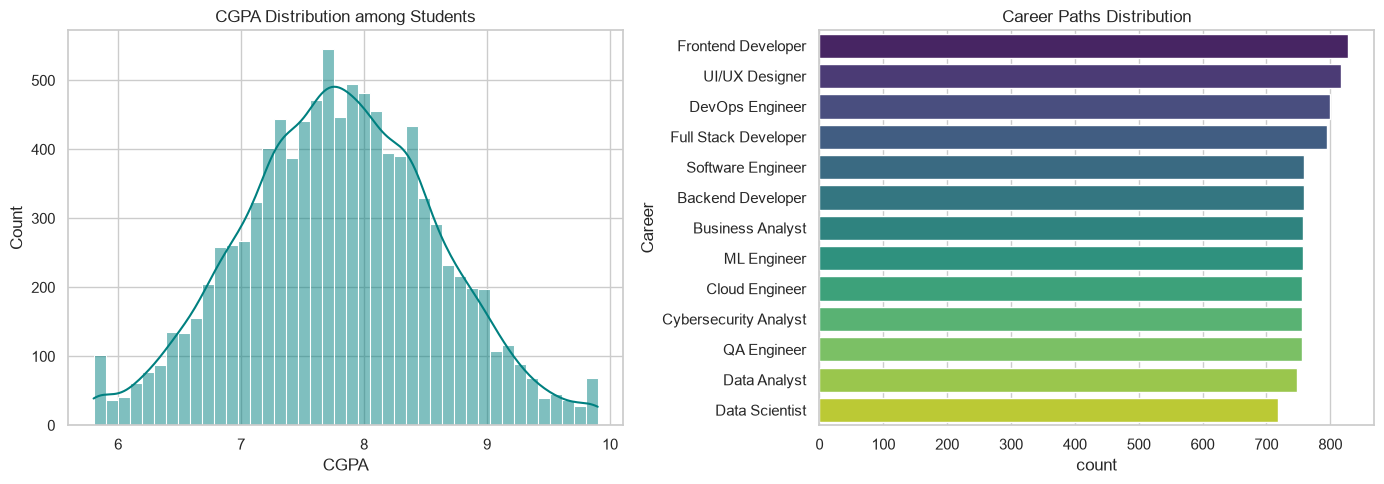

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: CGPA Distribution
sns.histplot(df['CGPA'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('CGPA Distribution among Students')

# Plot 2: Top Career Goals Count
sns.countplot(y=df['Career'], order=df['Career'].value_counts().index, ax=axes[1], palette='viridis')
axes[1].set_title('Career Paths Distribution')

plt.tight_layout()
plt.show()

In [17]:
# Feature preparation for Random Forest
X = df[['CGPA', 'Skills', 'Interest', 'Branch', 'Education']]
y = df['Career']

# Simple Train-Test Split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('skills_vec', TfidfVectorizer(), 'Skills'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Interest', 'Branch', 'Education'])
    ]
)

X_transformed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"Random Forest Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("--> Observation: Supervised ML fails due to random synthetic feature associations in dataset.")

Random Forest Accuracy Score: 7.95%
--> Observation: Supervised ML fails due to random synthetic feature associations in dataset.


In [18]:
# Text Feature Extraction
df['text_features'] = df['Skills'].astype(str) + " " + df['Interest'].astype(str)

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['text_features'])

# Sample User Input Test
test_skills = "Python, SQL, Machine Learning"
test_interest = "AI"
test_query = f"{test_skills} {test_interest}"

# Calculate Cosine Similarity
test_vec = vectorizer.transform([test_query])
similarities = cosine_similarity(test_vec, tfidf_matrix).flatten()

top_match_idx = similarities.argmax()
print(f"Input Query: '{test_query}'")
print(f"Top Match Score: {similarities[top_match_idx] * 100:.2f}%")
print(f"Predicted Career: {df.iloc[top_match_idx]['Career']}")
print(f"Matched Row Profile Skills: {df.iloc[top_match_idx]['Skills']}")

Input Query: 'Python, SQL, Machine Learning AI'
Top Match Score: 91.67%
Predicted Career: UI/UX Designer
Matched Row Profile Skills: SQL, Azure, Python, Machine Learning
